In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import pickle
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
import copy
 
from sympy import simplify, factor, cancel, expand
from scipy.special import jv, kv, hankel1, iv
 
from continuum_mechanics import vector
from continuum_mechanics import solids
 
from wave_plotter import plot_scalar_field, enable_latex_style
from extra_fns import (
    latex_print, grad, lap_vec, rotation,
    complete_strain_stress_ccst, classical_limit_system
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYMBOLIC SETUP
# ─────────────────────────────────────────────────────────────────────────────
r, th, z = smp.symbols("r, theta, z")
n        = smp.symbols("n", integer=True)
 
# exterior material
a, rho, mu, lam_lame, eta, ell = smp.symbols(
    "a, \\rho, \\mu, \\lambda, \\eta, \\ell", positive=True
)
kP, kS, varphi0, omega = smp.symbols(
    "k_P, k_S, \\varphi_0, \\omega", real=True
)
beta1, beta2 = smp.symbols("\\beta_1, \\beta_2", real=True)
 
# interior material (primes)
mu_p, lam_lame_p, eta_p, ell_p = smp.symbols(
    "\\mu', \\lambda', \\eta', \\ell'", positive=True
)
kP_p, kS_p, beta1_p, beta2_p = smp.symbols(
    "k_P', k_S', \\beta_1', \\beta_2'", real=True
)
 
# unknowns
# exterior: An (scattered P), Cn (evanescent SV), Dn (propagating SV)
# interior: Bn (refracted P), En (evanescent SV), Fn (propagating SV)
An, Bn, Cn, Dn, En, Fn = smp.symbols("A_n, B_n, C_n, D_n, E_n, F_n")
 
vareps = smp.Function("\\varepsilon")(n)
i      = smp.I
 
# displacement functions
u_r   = smp.Function("u_r")(r, th, z)
u_th  = smp.Function("u_{\\theta}")(r, th, z)
u_r_f = smp.Function("u_r^{(f)}")(r, th, z)
u_th_f= smp.Function("u_{\\theta}^{(f)}")(r, th, z)
 
u   = smp.Matrix([u_r,   u_th,   smp.Integer(0)])
u_f = smp.Matrix([u_r_f, u_th_f, smp.Integer(0)])
 
# potential functions
varphi_i = smp.Function("\\varphi^{(i)}")(r, th, z)
varphi_s = smp.Function("\\varphi^{(s)}")(r, th, z)
varphi_f = smp.Function("\\varphi^{(f)}")(r, th, z)
psi_s    = smp.Function("\\psi^{(s)}")(r, th, z)
psi_f    = smp.Function("\\psi^{(f)}")(r, th, z)
 
cyl = (r, th, z)
h   = (1, r, 1)
 
display(u)
display(u_f)

Matrix([
[       u_r(r, theta, z)],
[u_{\theta}(r, theta, z)],
[                      0]])

Matrix([
[       u_r^{(f)}(r, theta, z)],
[u_{\theta}^{(f)}(r, theta, z)],
[                            0]])

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# KINEMATICS AND STRESSES
# ─────────────────────────────────────────────────────────────────────────────
e_ten,   curv_ten   = solids.disp_def_cst(u,   cyl, h)
e_ten_f, curv_ten_f = solids.disp_def_cst(u_f, cyl, h)
 
w_vec,   w_ten   = rotation(u,   cyl, h)
w_vec_f, w_ten_f = rotation(u_f, cyl, h)
 
sigma_ten,   *_, mu_ten   = complete_strain_stress_ccst(
    e_ten,   curv_ten,   w_ten,   cyl, h, (lam_lame,   mu,   eta))
sigma_ten_f, *_, mu_ten_f = complete_strain_stress_ccst(
    e_ten_f, curv_ten_f, w_ten_f, cyl, h, (lam_lame_p, mu_p, eta_p))
 
plane_strain = {
    smp.diff(u_r,   z): 0,
    smp.diff(u_th,  z): 0,
    smp.diff(u_r_f, z): 0,
    smp.diff(u_th_f,z): 0,
}
 
sigma_ap   = simplify(sigma_ten.subs(plane_strain).doit())
sigma_ap_f = simplify(sigma_ten_f.subs(plane_strain).doit())
w_ap       = w_vec.subs(plane_strain).doit()
w_ap_f     = w_vec_f.subs(plane_strain).doit()
mu_ap      = mu_ten.subs(plane_strain).doit()
mu_ap_f    = mu_ten_f.subs(plane_strain).doit()

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# HELMHOLTZ POTENTIAL REPRESENTATION
#
# u = grad(φ) + curl(ψ ê_z)   (plane strain, no z-dependence)
#
#   u_r = ∂φ/∂r + (1/r)∂ψ/∂θ
#   u_θ = (1/r)∂φ/∂θ - ∂ψ/∂r
# ─────────────────────────────────────────────────────────────────────────────
def _u_from_potentials(phi_fn, psi_fn):
    psi_vec = smp.Matrix([0, 0, psi_fn])
    u_pot = (
        grad(phi_fn, cyl, h)
        + vector.curl(psi_vec, cyl, h)
    ).subs({smp.diff(phi_fn, z): 0, smp.diff(psi_fn, z): 0}).doit()
    return u_pot
 
 
u_ext_pot = _u_from_potentials(varphi_i + varphi_s, psi_s)
u_int_pot = _u_from_potentials(varphi_f, psi_f)
 
display(u_ext_pot)
display(u_int_pot)

Matrix([
[       Derivative(\varphi^{(i)}(r, theta, z), r) + Derivative(\varphi^{(s)}(r, theta, z), r) + Derivative(\psi^{(s)}(r, theta, z), theta)/r],
[-Derivative(\psi^{(s)}(r, theta, z), r) + (Derivative(\varphi^{(i)}(r, theta, z), theta) + Derivative(\varphi^{(s)}(r, theta, z), theta))/r],
[                                                                                                                                          0]])

Matrix([
[ Derivative(\varphi^{(f)}(r, theta, z), r) + Derivative(\psi^{(f)}(r, theta, z), theta)/r],
[-Derivative(\psi^{(f)}(r, theta, z), r) + Derivative(\varphi^{(f)}(r, theta, z), theta)/r],
[                                                                                        0]])

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUNDARY CONDITIONS
#
# at r = a, 6 continuity conditions:
#   BC1: u_r  (ext) = u_r  (int)
#   BC2: u_θ  (ext) = u_θ  (int)
#   BC3: ω_z  (ext) = ω_z  (int)          [rotation]
#   BC4: σ_rr (ext) = σ_rr (int)          [normal stress]
#   BC5: σ_rθ (ext) = σ_rθ (int)          [shear stress]
#   BC6: μ_rz (ext) = μ_rz (int)          [couple stress]
#
# unknowns: An, Bn, Cn, Dn, En, Fn
# ─────────────────────────────────────────────────────────────────────────────
 
# solutions for each potential
varphi_i_sln = (
    varphi0 * vareps * i**n
    * smp.besselj(n, kP*r)
    * smp.cos(n*th)
)
varphi_s_sln = (
    An * smp.hankel1(n, kP*r)
    * smp.cos(n*th)
)
varphi_f_sln = (
    Bn * smp.besselj(n, kP_p*r)
    * smp.cos(n*th)
)
psi_s_sln = (
    Cn * smp.besselk(n, beta1*r)
    + Dn * smp.hankel1(n, beta2*r)
) * smp.sin(n*th)
psi_f_sln = (
    En * smp.besseli(n, beta1_p*r)
    + Fn * smp.besselj(n, beta2_p*r)
) * smp.sin(n*th)
 
sln_subs_pot = {
    varphi_i: varphi_i_sln,
    varphi_s: varphi_s_sln,
    varphi_f: varphi_f_sln,
    psi_s:    psi_s_sln,
    psi_f:    psi_f_sln,
}
 
display(varphi_i_sln)
display(varphi_s_sln)
display(varphi_f_sln)
display(psi_s_sln)
display(psi_f_sln)

I**n*\varphi_0*\varepsilon(n)*cos(n*theta)*besselj(n, k_P*r)

A_n*cos(n*theta)*hankel1(n, k_P*r)

B_n*cos(n*theta)*besselj(n, k_P'*r)

(C_n*besselk(n, \beta_1*r) + D_n*hankel1(n, \beta_2*r))*sin(n*theta)

(E_n*besseli(n, \beta_1'*r) + F_n*besselj(n, \beta_2'*r))*sin(n*theta)

In [6]:
# substitute potentials into displacements
sln_subs_disp = {
    u_r:    u_ext_pot[0].subs(sln_subs_pot).doit(),
    u_th:   u_ext_pot[1].subs(sln_subs_pot).doit(),
    u_r_f:  u_int_pot[0].subs(sln_subs_pot).doit(),
    u_th_f: u_int_pot[1].subs(sln_subs_pot).doit(),
}
 
# BCs as symbolic equations
bdc_1 = smp.Eq(u_r,   u_r_f)
bdc_2 = smp.Eq(u_th,  u_th_f)
bdc_3 = smp.Eq(w_ap[2],       w_ap_f[2])
bdc_4 = smp.Eq(sigma_ap[0,0], sigma_ap_f[0,0])
bdc_5 = smp.Eq(sigma_ap[0,1], sigma_ap_f[0,1])
bdc_6 = smp.Eq(mu_ap[0,2],    mu_ap_f[0,2])
 
# substitute solutions and evaluate at r = a
def _apply(bdc):
    return factor(bdc.subs(sln_subs_disp).doit().subs({r: a}))
 
bdc_1_subs = _apply(bdc_1)
bdc_2_subs = _apply(bdc_2)
bdc_3_subs = _apply(bdc_3)
bdc_4_subs = _apply(bdc_4)
bdc_5_subs = _apply(bdc_5)
bdc_6_subs = _apply(bdc_6)
 
display(bdc_1_subs)
display(bdc_2_subs)
display(bdc_3_subs)
display(bdc_4_subs)
display(bdc_5_subs)
display(bdc_6_subs)

Eq(-(-I**n*\varphi_0*a*k_P*\varepsilon(n)*besselj(n - 1, a*k_P) + I**n*\varphi_0*a*k_P*\varepsilon(n)*besselj(n + 1, a*k_P) - A_n*a*k_P*hankel1(n - 1, a*k_P) + A_n*a*k_P*hankel1(n + 1, a*k_P) - 2*C_n*n*besselk(n, \beta_1*a) - 2*D_n*n*hankel1(n, \beta_2*a))*cos(n*theta)/(2*a), -(-B_n*a*k_P'*besselj(n - 1, a*k_P') + B_n*a*k_P'*besselj(n + 1, a*k_P') - 2*E_n*n*besseli(n, \beta_1'*a) - 2*F_n*n*besselj(n, \beta_2'*a))*cos(n*theta)/(2*a))

Eq((-2*I**n*\varphi_0*n*\varepsilon(n)*besselj(n, a*k_P) - 2*A_n*n*hankel1(n, a*k_P) + C_n*\beta_1*a*besselk(n - 1, \beta_1*a) + C_n*\beta_1*a*besselk(n + 1, \beta_1*a) - D_n*\beta_2*a*hankel1(n - 1, \beta_2*a) + D_n*\beta_2*a*hankel1(n + 1, \beta_2*a))*sin(n*theta)/(2*a), -(2*B_n*n*besselj(n, a*k_P') + E_n*\beta_1'*a*besseli(n - 1, \beta_1'*a) + E_n*\beta_1'*a*besseli(n + 1, \beta_1'*a) + F_n*\beta_2'*a*besselj(n - 1, \beta_2'*a) - F_n*\beta_2'*a*besselj(n + 1, \beta_2'*a))*sin(n*theta)/(2*a))

Eq(-(2*C_n*\beta_1**2*a**2*besselk(n, \beta_1*a) + C_n*\beta_1**2*a**2*besselk(n - 2, \beta_1*a) + C_n*\beta_1**2*a**2*besselk(n + 2, \beta_1*a) - 2*C_n*\beta_1*a*besselk(n - 1, \beta_1*a) - 2*C_n*\beta_1*a*besselk(n + 1, \beta_1*a) - 4*C_n*n**2*besselk(n, \beta_1*a) - 2*D_n*\beta_2**2*a**2*hankel1(n, \beta_2*a) + D_n*\beta_2**2*a**2*hankel1(n - 2, \beta_2*a) + D_n*\beta_2**2*a**2*hankel1(n + 2, \beta_2*a) + 2*D_n*\beta_2*a*hankel1(n - 1, \beta_2*a) - 2*D_n*\beta_2*a*hankel1(n + 1, \beta_2*a) - 4*D_n*n**2*hankel1(n, \beta_2*a))*sin(n*theta)/(8*a**2), -(2*E_n*\beta_1'**2*a**2*besseli(n, \beta_1'*a) + E_n*\beta_1'**2*a**2*besseli(n - 2, \beta_1'*a) + E_n*\beta_1'**2*a**2*besseli(n + 2, \beta_1'*a) + 2*E_n*\beta_1'*a*besseli(n - 1, \beta_1'*a) + 2*E_n*\beta_1'*a*besseli(n + 1, \beta_1'*a) - 4*E_n*n**2*besseli(n, \beta_1'*a) - 2*F_n*\beta_2'**2*a**2*besselj(n, \beta_2'*a) + F_n*\beta_2'**2*a**2*besselj(n - 2, \beta_2'*a) + F_n*\beta_2'**2*a**2*besselj(n + 2, \beta_2'*a) + 2*F_n*\beta_2'*a*

Eq((-2*I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n, a*k_P) + I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n - 2, a*k_P) + I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n + 2, a*k_P) + 2*I**n*\lambda*\varphi_0*a*k_P*\varepsilon(n)*besselj(n - 1, a*k_P) - 2*I**n*\lambda*\varphi_0*a*k_P*\varepsilon(n)*besselj(n + 1, a*k_P) - 4*I**n*\lambda*\varphi_0*n**2*\varepsilon(n)*besselj(n, a*k_P) - 4*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n, a*k_P) + 2*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n - 2, a*k_P) + 2*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n + 2, a*k_P) - 2*A_n*\lambda*a**2*k_P**2*hankel1(n, a*k_P) + A_n*\lambda*a**2*k_P**2*hankel1(n - 2, a*k_P) + A_n*\lambda*a**2*k_P**2*hankel1(n + 2, a*k_P) + 2*A_n*\lambda*a*k_P*hankel1(n - 1, a*k_P) - 2*A_n*\lambda*a*k_P*hankel1(n + 1, a*k_P) - 4*A_n*\lambda*n**2*hankel1(n, a*k_P) - 4*A_n*\mu*a**2*k_P**2*hankel1(n, a*k_P) + 2*A_n*\mu*a**2*k_P**2*hankel1(n - 2, a*k_P) + 2

Eq(-(16*I**n*\mu*\varphi_0*a**3*k_P*n*\varepsilon(n)*besselj(n - 1, a*k_P) - 16*I**n*\mu*\varphi_0*a**3*k_P*n*\varepsilon(n)*besselj(n + 1, a*k_P) - 32*I**n*\mu*\varphi_0*a**2*n*\varepsilon(n)*besselj(n, a*k_P) + 16*A_n*\mu*a**3*k_P*n*hankel1(n - 1, a*k_P) - 16*A_n*\mu*a**3*k_P*n*hankel1(n + 1, a*k_P) - 32*A_n*\mu*a**2*n*hankel1(n, a*k_P) + 6*C_n*\beta_1**4*\eta*a**4*besselk(n, \beta_1*a) + C_n*\beta_1**4*\eta*a**4*besselk(n - 4, \beta_1*a) + 4*C_n*\beta_1**4*\eta*a**4*besselk(n - 2, \beta_1*a) + 4*C_n*\beta_1**4*\eta*a**4*besselk(n + 2, \beta_1*a) + C_n*\beta_1**4*\eta*a**4*besselk(n + 4, \beta_1*a) - 4*C_n*\beta_1**3*\eta*a**3*besselk(n - 3, \beta_1*a) - 12*C_n*\beta_1**3*\eta*a**3*besselk(n - 1, \beta_1*a) - 12*C_n*\beta_1**3*\eta*a**3*besselk(n + 1, \beta_1*a) - 4*C_n*\beta_1**3*\eta*a**3*besselk(n + 3, \beta_1*a) - 16*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n, \beta_1*a) - 8*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n - 2, \beta_1*a) - 8*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n + 2, \bet

Eq(-\eta*(C_n*\beta_1**3*a**3*besselk(n - 3, \beta_1*a) + 3*C_n*\beta_1**3*a**3*besselk(n - 1, \beta_1*a) + 3*C_n*\beta_1**3*a**3*besselk(n + 1, \beta_1*a) + C_n*\beta_1**3*a**3*besselk(n + 3, \beta_1*a) - 4*C_n*\beta_1**2*a**2*besselk(n, \beta_1*a) - 2*C_n*\beta_1**2*a**2*besselk(n - 2, \beta_1*a) - 2*C_n*\beta_1**2*a**2*besselk(n + 2, \beta_1*a) - 4*C_n*\beta_1*a*n**2*besselk(n - 1, \beta_1*a) - 4*C_n*\beta_1*a*n**2*besselk(n + 1, \beta_1*a) - 4*C_n*\beta_1*a*besselk(n - 1, \beta_1*a) - 4*C_n*\beta_1*a*besselk(n + 1, \beta_1*a) - 16*C_n*n**2*besselk(n, \beta_1*a) - D_n*\beta_2**3*a**3*hankel1(n - 3, \beta_2*a) + 3*D_n*\beta_2**3*a**3*hankel1(n - 1, \beta_2*a) - 3*D_n*\beta_2**3*a**3*hankel1(n + 1, \beta_2*a) + D_n*\beta_2**3*a**3*hankel1(n + 3, \beta_2*a) + 4*D_n*\beta_2**2*a**2*hankel1(n, \beta_2*a) - 2*D_n*\beta_2**2*a**2*hankel1(n - 2, \beta_2*a) - 2*D_n*\beta_2**2*a**2*hankel1(n + 2, \beta_2*a) + 4*D_n*\beta_2*a*n**2*hankel1(n - 1, \beta_2*a) - 4*D_n*\beta_2*a*n**2*hankel1(n + 1,

In [7]:
# clean up: divide by angular factors and common prefactors
factor_cos = smp.cos(n*th)
factor_sin = smp.sin(n*th)
 
bdc_1_clean = smp.Eq(cancel(2*a * bdc_1_subs.lhs / factor_cos),
                     cancel(2*a * bdc_1_subs.rhs / factor_cos))
bdc_2_clean = smp.Eq(cancel(2*a * bdc_2_subs.lhs / factor_sin),
                     cancel(2*a * bdc_2_subs.rhs / factor_sin))
bdc_3_clean = smp.Eq(cancel(8*a**2 * bdc_3_subs.lhs / factor_sin),
                     cancel(8*a**2 * bdc_3_subs.rhs / factor_sin))
bdc_4_clean = smp.Eq(cancel(4*a**2 * bdc_4_subs.lhs / factor_cos),
                     cancel(4*a**2 * bdc_4_subs.rhs / factor_cos))
bdc_5_clean = smp.Eq(cancel(16*a**4 * bdc_5_subs.lhs / factor_sin),
                     cancel(16*a**4 * bdc_5_subs.rhs / factor_sin))
bdc_6_clean = smp.Eq(cancel(4*a**3 * bdc_6_subs.lhs / factor_sin),
                     cancel(4*a**3 * bdc_6_subs.rhs / factor_sin))
 
display(bdc_1_clean)
display(bdc_2_clean)
display(bdc_3_clean)
display(bdc_4_clean)
display(bdc_5_clean)
display(bdc_6_clean)

Eq(I**n*\varphi_0*a*k_P*\varepsilon(n)*besselj(n - 1, a*k_P) - I**n*\varphi_0*a*k_P*\varepsilon(n)*besselj(n + 1, a*k_P) + A_n*a*k_P*hankel1(n - 1, a*k_P) - A_n*a*k_P*hankel1(n + 1, a*k_P) + 2*C_n*n*besselk(n, \beta_1*a) + 2*D_n*n*hankel1(n, \beta_2*a), B_n*a*k_P'*besselj(n - 1, a*k_P') - B_n*a*k_P'*besselj(n + 1, a*k_P') + 2*E_n*n*besseli(n, \beta_1'*a) + 2*F_n*n*besselj(n, \beta_2'*a))

Eq(-2*I**n*\varphi_0*n*\varepsilon(n)*besselj(n, a*k_P) - 2*A_n*n*hankel1(n, a*k_P) + C_n*\beta_1*a*besselk(n - 1, \beta_1*a) + C_n*\beta_1*a*besselk(n + 1, \beta_1*a) - D_n*\beta_2*a*hankel1(n - 1, \beta_2*a) + D_n*\beta_2*a*hankel1(n + 1, \beta_2*a), -2*B_n*n*besselj(n, a*k_P') - E_n*\beta_1'*a*besseli(n - 1, \beta_1'*a) - E_n*\beta_1'*a*besseli(n + 1, \beta_1'*a) - F_n*\beta_2'*a*besselj(n - 1, \beta_2'*a) + F_n*\beta_2'*a*besselj(n + 1, \beta_2'*a))

Eq(-2*C_n*\beta_1**2*a**2*besselk(n, \beta_1*a) - C_n*\beta_1**2*a**2*besselk(n - 2, \beta_1*a) - C_n*\beta_1**2*a**2*besselk(n + 2, \beta_1*a) + 2*C_n*\beta_1*a*besselk(n - 1, \beta_1*a) + 2*C_n*\beta_1*a*besselk(n + 1, \beta_1*a) + 4*C_n*n**2*besselk(n, \beta_1*a) + 2*D_n*\beta_2**2*a**2*hankel1(n, \beta_2*a) - D_n*\beta_2**2*a**2*hankel1(n - 2, \beta_2*a) - D_n*\beta_2**2*a**2*hankel1(n + 2, \beta_2*a) - 2*D_n*\beta_2*a*hankel1(n - 1, \beta_2*a) + 2*D_n*\beta_2*a*hankel1(n + 1, \beta_2*a) + 4*D_n*n**2*hankel1(n, \beta_2*a), -2*E_n*\beta_1'**2*a**2*besseli(n, \beta_1'*a) - E_n*\beta_1'**2*a**2*besseli(n - 2, \beta_1'*a) - E_n*\beta_1'**2*a**2*besseli(n + 2, \beta_1'*a) - 2*E_n*\beta_1'*a*besseli(n - 1, \beta_1'*a) - 2*E_n*\beta_1'*a*besseli(n + 1, \beta_1'*a) + 4*E_n*n**2*besseli(n, \beta_1'*a) + 2*F_n*\beta_2'**2*a**2*besselj(n, \beta_2'*a) - F_n*\beta_2'**2*a**2*besselj(n - 2, \beta_2'*a) - F_n*\beta_2'**2*a**2*besselj(n + 2, \beta_2'*a) - 2*F_n*\beta_2'*a*besselj(n - 1, \beta_2'*a

Eq(-2*I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n, a*k_P) + I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n - 2, a*k_P) + I**n*\lambda*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n + 2, a*k_P) + 2*I**n*\lambda*\varphi_0*a*k_P*\varepsilon(n)*besselj(n - 1, a*k_P) - 2*I**n*\lambda*\varphi_0*a*k_P*\varepsilon(n)*besselj(n + 1, a*k_P) - 4*I**n*\lambda*\varphi_0*n**2*\varepsilon(n)*besselj(n, a*k_P) - 4*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n, a*k_P) + 2*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n - 2, a*k_P) + 2*I**n*\mu*\varphi_0*a**2*k_P**2*\varepsilon(n)*besselj(n + 2, a*k_P) - 2*A_n*\lambda*a**2*k_P**2*hankel1(n, a*k_P) + A_n*\lambda*a**2*k_P**2*hankel1(n - 2, a*k_P) + A_n*\lambda*a**2*k_P**2*hankel1(n + 2, a*k_P) + 2*A_n*\lambda*a*k_P*hankel1(n - 1, a*k_P) - 2*A_n*\lambda*a*k_P*hankel1(n + 1, a*k_P) - 4*A_n*\lambda*n**2*hankel1(n, a*k_P) - 4*A_n*\mu*a**2*k_P**2*hankel1(n, a*k_P) + 2*A_n*\mu*a**2*k_P**2*hankel1(n - 2, a*k_P) + 2*

Eq(-16*I**n*\mu*\varphi_0*a**3*k_P*n*\varepsilon(n)*besselj(n - 1, a*k_P) + 16*I**n*\mu*\varphi_0*a**3*k_P*n*\varepsilon(n)*besselj(n + 1, a*k_P) + 32*I**n*\mu*\varphi_0*a**2*n*\varepsilon(n)*besselj(n, a*k_P) - 16*A_n*\mu*a**3*k_P*n*hankel1(n - 1, a*k_P) + 16*A_n*\mu*a**3*k_P*n*hankel1(n + 1, a*k_P) + 32*A_n*\mu*a**2*n*hankel1(n, a*k_P) - 6*C_n*\beta_1**4*\eta*a**4*besselk(n, \beta_1*a) - C_n*\beta_1**4*\eta*a**4*besselk(n - 4, \beta_1*a) - 4*C_n*\beta_1**4*\eta*a**4*besselk(n - 2, \beta_1*a) - 4*C_n*\beta_1**4*\eta*a**4*besselk(n + 2, \beta_1*a) - C_n*\beta_1**4*\eta*a**4*besselk(n + 4, \beta_1*a) + 4*C_n*\beta_1**3*\eta*a**3*besselk(n - 3, \beta_1*a) + 12*C_n*\beta_1**3*\eta*a**3*besselk(n - 1, \beta_1*a) + 12*C_n*\beta_1**3*\eta*a**3*besselk(n + 1, \beta_1*a) + 4*C_n*\beta_1**3*\eta*a**3*besselk(n + 3, \beta_1*a) + 16*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n, \beta_1*a) + 8*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n - 2, \beta_1*a) + 8*C_n*\beta_1**2*\eta*a**2*n**2*besselk(n + 2, \beta

Eq(-C_n*\beta_1**3*\eta*a**3*besselk(n - 3, \beta_1*a) - 3*C_n*\beta_1**3*\eta*a**3*besselk(n - 1, \beta_1*a) - 3*C_n*\beta_1**3*\eta*a**3*besselk(n + 1, \beta_1*a) - C_n*\beta_1**3*\eta*a**3*besselk(n + 3, \beta_1*a) + 4*C_n*\beta_1**2*\eta*a**2*besselk(n, \beta_1*a) + 2*C_n*\beta_1**2*\eta*a**2*besselk(n - 2, \beta_1*a) + 2*C_n*\beta_1**2*\eta*a**2*besselk(n + 2, \beta_1*a) + 4*C_n*\beta_1*\eta*a*n**2*besselk(n - 1, \beta_1*a) + 4*C_n*\beta_1*\eta*a*n**2*besselk(n + 1, \beta_1*a) + 4*C_n*\beta_1*\eta*a*besselk(n - 1, \beta_1*a) + 4*C_n*\beta_1*\eta*a*besselk(n + 1, \beta_1*a) + 16*C_n*\eta*n**2*besselk(n, \beta_1*a) + D_n*\beta_2**3*\eta*a**3*hankel1(n - 3, \beta_2*a) - 3*D_n*\beta_2**3*\eta*a**3*hankel1(n - 1, \beta_2*a) + 3*D_n*\beta_2**3*\eta*a**3*hankel1(n + 1, \beta_2*a) - D_n*\beta_2**3*\eta*a**3*hankel1(n + 3, \beta_2*a) - 4*D_n*\beta_2**2*\eta*a**2*hankel1(n, \beta_2*a) + 2*D_n*\beta_2**2*\eta*a**2*hankel1(n - 2, \beta_2*a) + 2*D_n*\beta_2**2*\eta*a**2*hankel1(n + 2, \beta_2*

In [8]:
# build 6×6 linear system
A_mat, b_vec = smp.linear_eq_to_matrix(
    [bdc_1_clean, bdc_2_clean, bdc_3_clean,
     bdc_4_clean, bdc_5_clean, bdc_6_clean],
    [An, Bn, Cn, Dn, En, Fn]
)
 
display(simplify(A_mat))
display(simplify(b_vec))

Matrix([
[                                                                                                                                                                                                                                                                                                                        a*k_P*(hankel1(n - 1, a*k_P) - hankel1(n + 1, a*k_P)),                                                                                                                                                                                                                                                                                                                                                                               a*k_P'*(-besselj(n - 1, a*k_P') + besselj(n + 1, a*k_P')),                                                                                                                                                                                                       

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                I**n*\varphi_0*a*k_P*(-besselj(n - 1, a*k_P) + besselj(n + 1, a*k_P))*\varepsilon(n)],
[                                                                                                                                                                                                                                                                                                                                                                                                                 2*I**n*\varphi_0*n*\varepsilon(n)*besselj(n, a*k_P)],
[                                                                              

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSICAL LIMIT  (verification)
# both ell→0 and ell'→0 simultaneously
# expected: Cn → 0, En → 0  (evanescent terms vanish)
#           An, Dn, Bn, Fn → classical P-SV elastic scattering coefficients
# ─────────────────────────────────────────────────────────────────────────────
A_cl, b_cl, sol_cl = classical_limit_system(
    A_mat, b_vec,
    beta1_list = [beta1,  beta1_p],
    beta2_list = [beta2,  beta2_p],
    kS_list    = [kS,     kS_p],
    eta_list   = [eta,    eta_p],
    var_names  = ["An", "Bn", "Cn", "Dn", "En", "Fn"],
    force_stop_after_zeros = True
)

  Pass: zeroed ['Cn', 'En'], remaining: ['An', 'Bn', 'Dn', 'Fn']
Classical limit → zero : ['Cn', 'En']
Classical limit → live : ['An', 'Bn', 'Dn', 'Fn']
force_stop_after_zeros=True — skipping symbolic solve.
Classically zero coefficients confirmed. Remaining coefficients require numerical evaluation per (n, params).


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# ADIMENSIONALIZATION
#
# khatP  = k_P * a,   khatS  = k_S * a,   lhat  = ell / a
# khatP' = k_P'* a,   khatS' = k_S'* a,   lhat' = ell'/ a
# mu_ratio = mu'/mu
# Lamé relation: lam = mu*((khatS/khatP)^2 - 2)
#                lam'= mu'*((khatS'/khatP')^2 - 2)
#
# free symbols after adim: {n, khatP, khatS, lhat, khatP', khatS', lhat', mu_ratio}
# ─────────────────────────────────────────────────────────────────────────────
khatP, khatS, lhat, khatP_p, khatS_p, lhat_p, mu_ratio = smp.symbols(
    "\\hat{k}_P, \\hat{k}_S, \\hat{\\ell}, "
    "\\hat{k}_P', \\hat{k}_S', \\hat{\\ell}', \\mu'/\\mu",
    positive=True
)
 
_cache_file = "cache/P_elastic_A_b_ad.pkl"
 
if os.path.exists(_cache_file):
    print("Loading A_ad, b_ad from cache...")
    with open(_cache_file, "rb") as f:
        A_ad, b_ad = pickle.load(f)
    print("Done.")
 
else:
    print("Computing A_ad, b_ad (this may take several minutes)...")
 
    # step 1: eta = mu*ell^2,  eta' = mu'*ell'^2
    A_ad = A_mat.subs({eta: mu*ell**2, eta_p: mu_p*ell_p**2})
    b_ad = b_vec.subs({eta: mu*ell**2, eta_p: mu_p*ell_p**2})
 
    # step 2: beta definitions (exterior SV and interior SV)
    _beta_subs = {
        beta1:   smp.sqrt((1 + smp.sqrt(1 + 4*ell**2   * kS**2))    / (2*ell**2)),
        beta2:   smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2   * kS**2))   / (2*ell**2)),
        beta1_p: smp.sqrt((1 + smp.sqrt(1 + 4*ell_p**2  * kS_p**2)) / (2*ell_p**2)),
        beta2_p: kS_p,   # propagating SV inside: β2' = k_S'
    }
    A_ad = A_ad.subs(_beta_subs)
    b_ad = b_ad.subs(_beta_subs)
 
    # step 3: dimensionless variables
    #   kP = khatP/a,  kS = khatS/a,  ell = lhat*a
    #   kP'= khatP'/a, kS'= khatS'/a, ell'= lhat'*a
    #   mu'= mu_ratio*mu
    _subs_dim = {
        kP:    khatP/a,    kS:   khatS/a,   ell:   lhat*a,
        kP_p:  khatP_p/a,  kS_p: khatS_p/a, ell_p: lhat_p*a,
        mu_p:  mu_ratio * mu,
        varphi0: 1,
    }
    A_ad = A_ad.subs(_subs_dim)
    b_ad = b_ad.subs(_subs_dim)
 
    # step 4: Lamé relations
    #   lam  = mu  * ((khatS /khatP )^2 - 2)
    #   lam' = mu' * ((khatS'/khatP')^2 - 2)
    _lame_subs = {
        lam_lame:   mu   * ((khatS  / khatP )**2 - 2),
        lam_lame_p: mu_p * ((khatS_p / khatP_p)**2 - 2),
    }
    A_ad = A_ad.subs(_lame_subs)
    b_ad = b_ad.subs(_lame_subs)
    # substitute mu' = mu_ratio*mu again after lame subs
    A_ad = A_ad.subs({mu_p: mu_ratio * mu})
    b_ad = b_ad.subs({mu_p: mu_ratio * mu})
 
    # step 5: vareps
    _eps = smp.Piecewise((1, smp.Eq(n, 0)), (2, True))
    A_ad = A_ad.subs(vareps, _eps)
    b_ad = b_ad.subs(vareps, _eps)
 
    # step 6: divide stress/couple rows (3,4,5) by mu
    for col in range(6):
        for row in [3, 4, 5]:
            A_ad[row, col] = cancel(A_ad[row, col] / mu)
    for row in [3, 4, 5]:
        b_ad[row] = cancel(b_ad[row] / mu)
 
    # step 7: set mu=1 and a=1
    A_ad = A_ad.subs({mu: 1, a: 1})
    b_ad = b_ad.subs({mu: 1, a: 1})
 
    print("Free symbols in A_ad:", A_ad.free_symbols)
    print("Free symbols in b_ad:", b_ad.free_symbols)
 
    os.makedirs("cache", exist_ok=True)
    with open(_cache_file, "wb") as f:
        pickle.dump((A_ad, b_ad), f)
    print("Computed and saved to cache.")
 
print("Free symbols in A_ad:", A_ad.free_symbols)
print("Free symbols in b_ad:", b_ad.free_symbols)

Loading A_ad, b_ad from cache...
Done.
Free symbols in A_ad: {\hat{k}_P', \hat{k}_S, \mu'/\mu, \hat{k}_S', \hat{k}_P, \hat{\ell}', n, \hat{\ell}}
Free symbols in b_ad: {\hat{k}_P, n, \hat{k}_S}


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# LAMBDIFY  →  A_func and b_func take
# (n, khatP, khatS, lhat, khatP', khatS', lhat', mu_ratio)
# ─────────────────────────────────────────────────────────────────────────────
_bessel_mods = [
    {"besselj": jv, "besselk": kv, "hankel1": hankel1, "besseli": iv},
    "numpy"
]
_sym_args = (n, khatP, khatS, lhat, khatP_p, khatS_p, lhat_p, mu_ratio)
 
A_func = smp.lambdify(_sym_args, A_ad.tolist(), modules=_bessel_mods)
b_func = smp.lambdify(_sym_args, b_ad.tolist(), modules=_bessel_mods)
 
 
def solve_coefficients(khatP_val, khatS_val, lhat_val,
                        khatP_p_val, khatS_p_val, lhat_p_val,
                        mu_ratio_val, Nmax):
    """Solve the 6×6 system for each n."""
    An_v, Bn_v, Cn_v, Dn_v, En_v, Fn_v = {}, {}, {}, {}, {}, {}
    for n_val in range(Nmax + 1):
        try:
            A_num = np.array(
                A_func(n_val, khatP_val, khatS_val, lhat_val,
                       khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val),
                dtype=complex
            )
            b_num = np.array(
                b_func(n_val, khatP_val, khatS_val, lhat_val,
                       khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val),
                dtype=complex
            ).flatten()
            sol = np.linalg.solve(A_num, b_num)
            An_v[n_val] = sol[0]; Bn_v[n_val] = sol[1]
            Cn_v[n_val] = sol[2]; Dn_v[n_val] = sol[3]
            En_v[n_val] = sol[4]; Fn_v[n_val] = sol[5]
        except np.linalg.LinAlgError:
            print(f"  [singular] n={n_val}")
            An_v[n_val] = Bn_v[n_val] = Cn_v[n_val] = 0.0
            Dn_v[n_val] = En_v[n_val] = Fn_v[n_val] = 0.0
    return An_v, Bn_v, Cn_v, Dn_v, En_v, Fn_v

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIELD FUNCTIONS
#
# Bessel derivative recurrences (dimensionless, a=1):
#   f_n'(x) = [f_{n-1}(x) - f_{n+1}(x)] / 2    for J_n, H_n^(1)
#   K_n'(x) = -[K_{n-1}(x) + K_{n+1}(x)] / 2
#   I_n'(x) = [I_{n-1}(x) + I_{n+1}(x)] / 2
# ─────────────────────────────────────────────────────────────────────────────
def _b1(khatS_val, lhat_val):
    return np.sqrt((1 + np.sqrt(1 + 4*lhat_val**2 * khatS_val**2))
                   / (2*lhat_val**2))
 
def _b2(khatS_val, lhat_val):
    return np.sqrt(-(1 - np.sqrt(1 + 4*lhat_val**2 * khatS_val**2))
                   / (2*lhat_val**2))
 
def _eps(nv): return 1 if nv == 0 else 2
 
 
def phi_fields(R_hat, TH, khatP_val, khatS_val, lhat_val,
               khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax):
    """
    Returns PHI_ext (incident+scattered P) and PHI_int (refracted P).
    PHI_ext valid for r >= 1, PHI_int valid for r < 1.
    """
    An_v, Bn_v, *_ = solve_coefficients(
        khatP_val, khatS_val, lhat_val,
        khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
    )
 
    phi_ext = np.zeros_like(R_hat, dtype=complex)
    phi_int = np.zeros_like(R_hat, dtype=complex)
 
    for n_val in range(Nmax + 1):
        # exterior: J_n(kP*r) + An*H_n(kP*r)
        term_e = (
            _eps(n_val) * (1j)**n_val * jv(n_val, khatP_val * R_hat)
            + An_v[n_val] * hankel1(n_val, khatP_val * R_hat)
        ) * np.cos(n_val * TH)
        # interior: Bn*J_n(kP'*r)
        term_i = (
            Bn_v[n_val] * jv(n_val, khatP_p_val * R_hat)
        ) * np.cos(n_val * TH)
 
        phi_ext += np.nan_to_num(term_e, nan=0.0, posinf=0.0, neginf=0.0)
        phi_int += np.nan_to_num(term_i, nan=0.0, posinf=0.0, neginf=0.0)
 
    return phi_ext, phi_int
 
 
def psi_fields(R_hat, TH, khatP_val, khatS_val, lhat_val,
               khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax):
    """
    Returns PSI_ext (scattered SV) and PSI_int (refracted SV).
    """
    An_v, Bn_v, Cn_v, Dn_v, En_v, Fn_v = solve_coefficients(
        khatP_val, khatS_val, lhat_val,
        khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
    )
    b1  = _b1(khatS_val, lhat_val)
    b2  = _b2(khatS_val, lhat_val)
    b1p = _b1(khatS_p_val, lhat_p_val)
 
    psi_ext = np.zeros_like(R_hat, dtype=complex)
    psi_int = np.zeros_like(R_hat, dtype=complex)
 
    for n_val in range(Nmax + 1):
        term_e = (
            Cn_v[n_val] * kv(n_val, b1 * R_hat)
            + Dn_v[n_val] * hankel1(n_val, b2 * R_hat)
        ) * np.sin(n_val * TH)
        term_i = (
            En_v[n_val] * iv(n_val, b1p * R_hat)
            + Fn_v[n_val] * jv(n_val, khatS_p_val * R_hat)
        ) * np.sin(n_val * TH)
 
        psi_ext += np.nan_to_num(term_e, nan=0.0, posinf=0.0, neginf=0.0)
        psi_int += np.nan_to_num(term_i, nan=0.0, posinf=0.0, neginf=0.0)
 
    return psi_ext, psi_int
 
 
def displacement_fields(R_hat, TH, khatP_val, khatS_val, lhat_val,
                         khatP_p_val, khatS_p_val, lhat_p_val,
                         mu_ratio_val, Nmax):
    """
    Compute u_r and u_θ from potentials via Helmholtz representation.
 
    Exterior (r >= 1):
      u_r = dφ_ext/dr + (1/r)dψ_ext/dθ
      u_θ = (1/r)dφ_ext/dθ - dψ_ext/dr
 
    Interior (r < 1):
      u_r = dφ_int/dr + (1/r)dψ_int/dθ
      u_θ = (1/r)dφ_int/dθ - dψ_int/dr
    """
    An_v, Bn_v, Cn_v, Dn_v, En_v, Fn_v = solve_coefficients(
        khatP_val, khatS_val, lhat_val,
        khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
    )
    b1  = _b1(khatS_val, lhat_val)
    b2  = _b2(khatS_val, lhat_val)
    b1p = _b1(khatS_p_val, lhat_p_val)
 
    R_safe = np.where(R_hat == 0, 1e-12, R_hat)
 
    ur  = np.zeros_like(R_hat, dtype=complex)
    uth = np.zeros_like(R_hat, dtype=complex)
 
    mask_int = R_hat < 1.0
    mask_ext = ~mask_int
 
    for n_val in range(Nmax + 1):
        eps  = _eps(n_val)
        in_n = (1j)**n_val
 
        # ── φ exterior ────────────────────────────────────────────────────
        kPr = khatP_val * R_hat
        dJn_dr_e  = khatP_val * (jv(n_val-1, kPr) - jv(n_val+1, kPr)) / 2
        dHn_dr_e  = khatP_val * (hankel1(n_val-1, kPr)
                                  - hankel1(n_val+1, kPr)) / 2
        dphi_ext_dr  = (eps*in_n*dJn_dr_e  + An_v[n_val]*dHn_dr_e) * np.cos(n_val*TH)
        dphi_ext_dth = -(eps*in_n*jv(n_val,kPr)
                          + An_v[n_val]*hankel1(n_val,kPr)) * n_val * np.sin(n_val*TH)
 
        # ── φ interior ────────────────────────────────────────────────────
        kPpr = khatP_p_val * R_hat
        dJn_dr_i   = khatP_p_val * (jv(n_val-1, kPpr) - jv(n_val+1, kPpr)) / 2
        dphi_int_dr  = Bn_v[n_val] * dJn_dr_i  * np.cos(n_val*TH)
        dphi_int_dth = -Bn_v[n_val] * jv(n_val,kPpr) * n_val * np.sin(n_val*TH)
 
        # ── ψ exterior ────────────────────────────────────────────────────
        b1r = b1 * R_hat; b2r = b2 * R_hat
        dKn_dr  = -b1 * (kv(n_val-1, b1r) + kv(n_val+1, b1r)) / 2
        dHSn_dr =  b2 * (hankel1(n_val-1, b2r) - hankel1(n_val+1, b2r)) / 2
        dpsi_ext_dr  = (Cn_v[n_val]*dKn_dr
                         + Dn_v[n_val]*dHSn_dr) * np.sin(n_val*TH)
        dpsi_ext_dth = (Cn_v[n_val]*kv(n_val,b1r)
                         + Dn_v[n_val]*hankel1(n_val,b2r)) * n_val * np.cos(n_val*TH)
 
        # ── ψ interior ────────────────────────────────────────────────────
        b1pr = b1p * R_hat; kSpr = khatS_p_val * R_hat
        dIn_dr  = b1p * (iv(n_val-1, b1pr) + iv(n_val+1, b1pr)) / 2
        dJSn_dr = khatS_p_val * (jv(n_val-1, kSpr) - jv(n_val+1, kSpr)) / 2
        dpsi_int_dr  = (En_v[n_val]*dIn_dr
                         + Fn_v[n_val]*dJSn_dr) * np.sin(n_val*TH)
        dpsi_int_dth = (En_v[n_val]*iv(n_val,b1pr)
                         + Fn_v[n_val]*jv(n_val,kSpr)) * n_val * np.cos(n_val*TH)
 
        # ── assemble ──────────────────────────────────────────────────────
        ur_term  = np.where(
            mask_ext,
            dphi_ext_dr  + dpsi_ext_dth / R_safe,
            dphi_int_dr  + dpsi_int_dth / R_safe
        )
        uth_term = np.where(
            mask_ext,
            dphi_ext_dth / R_safe - dpsi_ext_dr,
            dphi_int_dth / R_safe - dpsi_int_dr
        )
 
        ur  += np.nan_to_num(ur_term,  nan=0.0, posinf=0.0, neginf=0.0)
        uth += np.nan_to_num(uth_term, nan=0.0, posinf=0.0, neginf=0.0)
 
        if np.any(~np.isfinite(ur_term)) or np.any(~np.isfinite(uth_term)):
            print(f"  [nan_to_num disp] n={n_val}")
 
    return ur, uth


Computing P elastic field:
  khatP=2.0, khatS=4.0, lhat=0.1
  khatP'=4, khatS'=6, lhat'=0.1
  mu'/mu=2.0

  Computing potentials...

  Computing displacements...


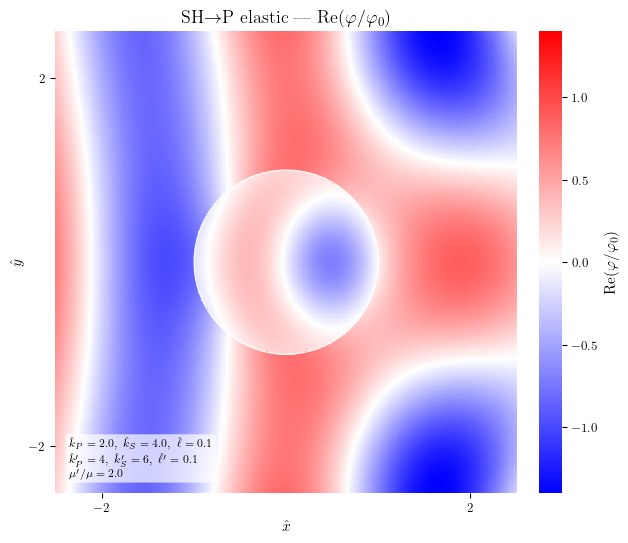

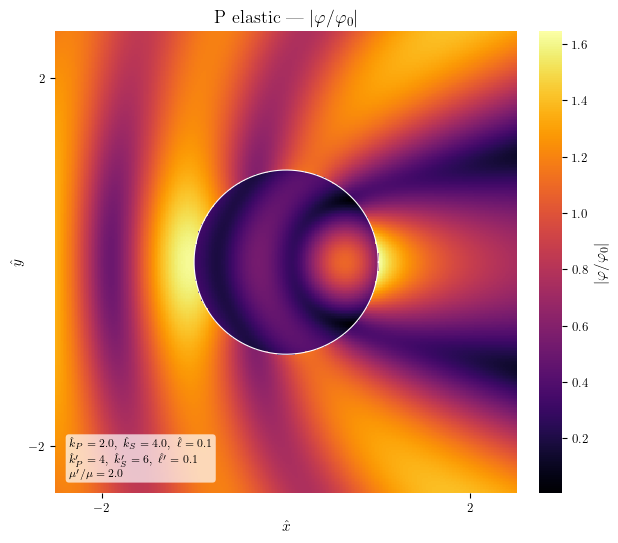

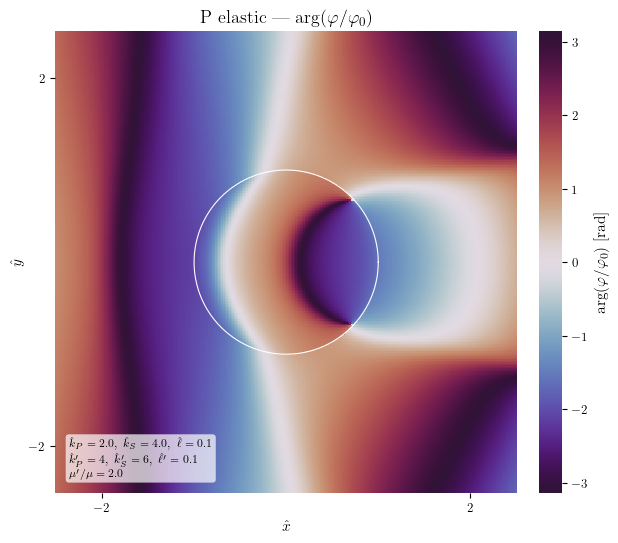

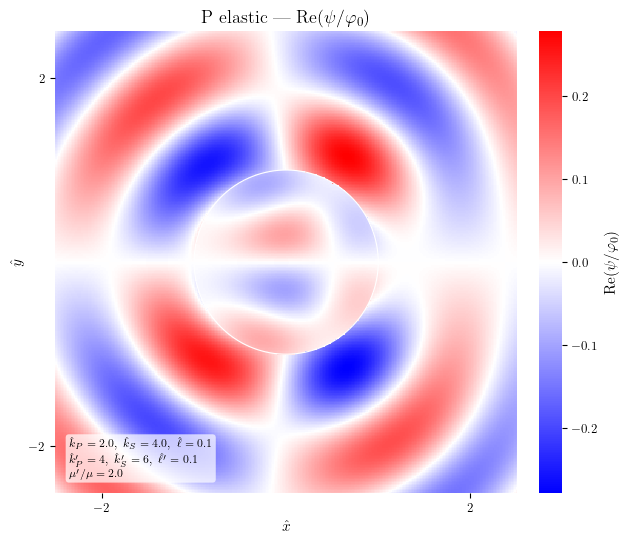

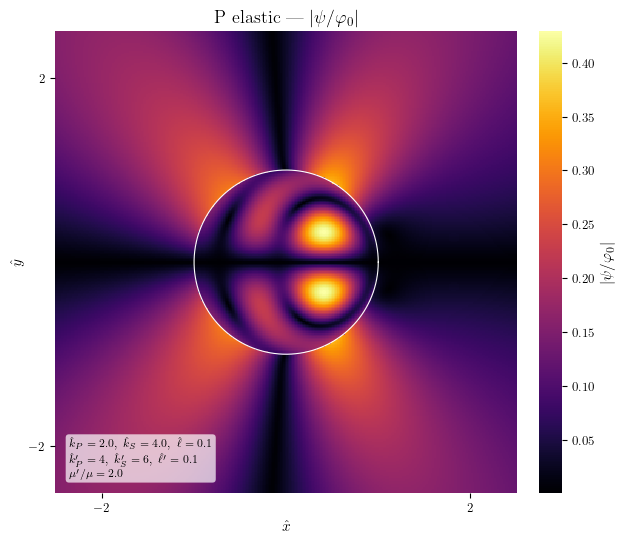

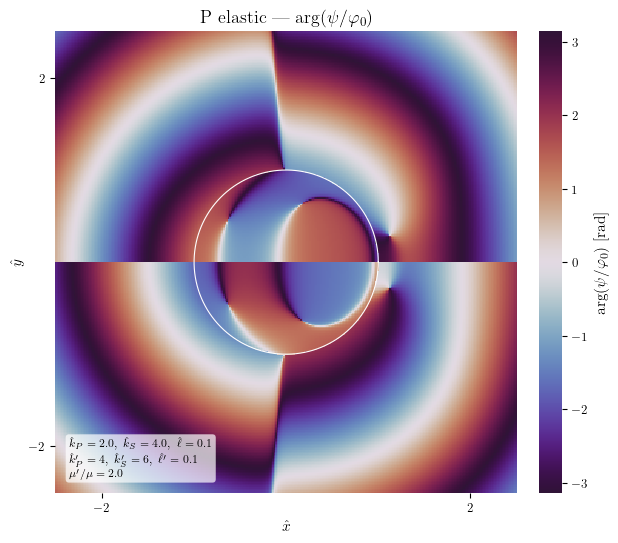

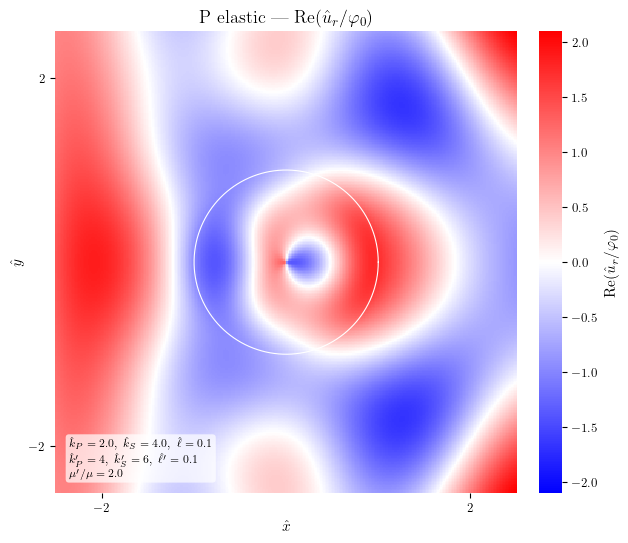

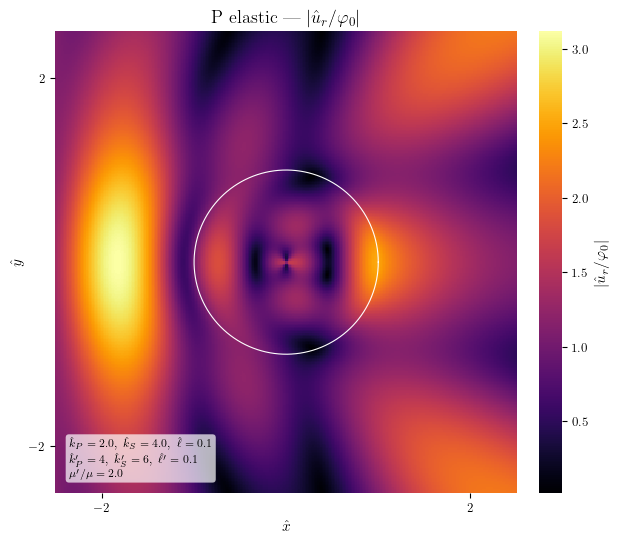

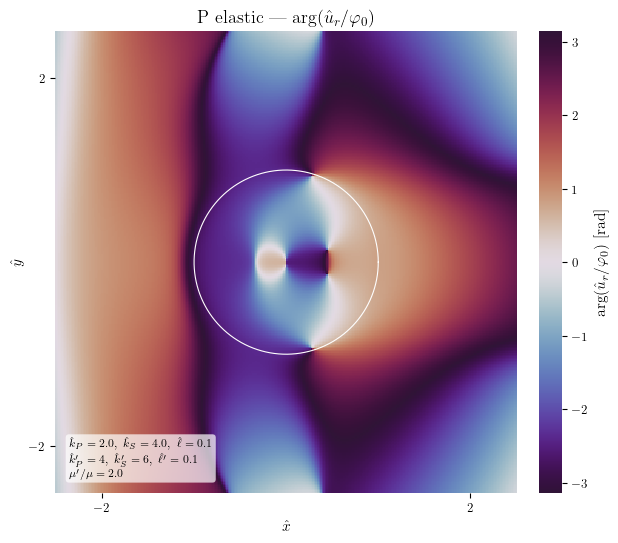

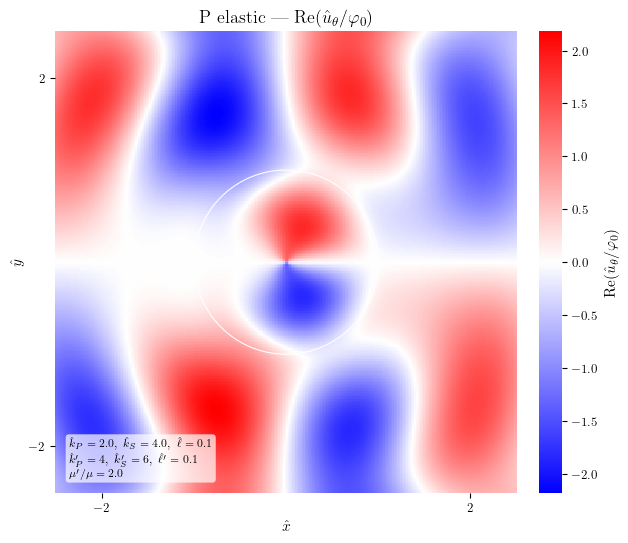

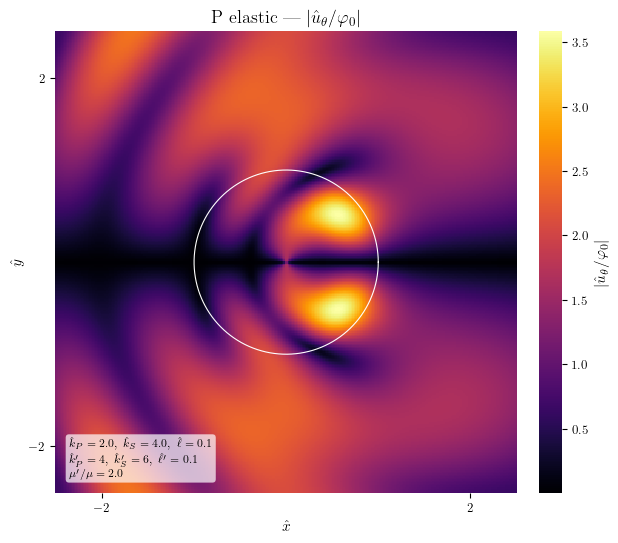

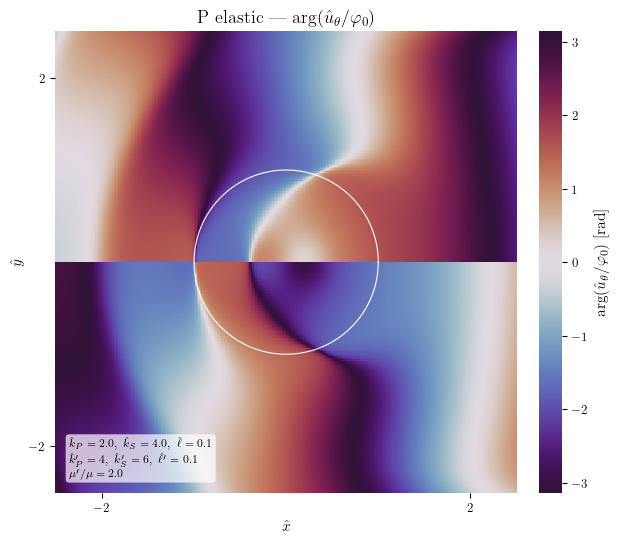

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ν=1/3 → c_P/c_S = 2 → khatS = 2*khatP
# ─────────────────────────────────────────────────────────────────────────────
khatP_val   = 2.0
khatS_val   = 4.0      # ν=1/3 → khatS = 2*khatP
lhat_val    = 0.1
khatP_p_val = 4      # stiffer interior: shorter P wavelength
khatS_p_val = 6      # khatS'/khatP' ≈ 1.8
lhat_p_val  = 0.1
mu_ratio_val= 2.0
Nmax        = 100
 
resolution = 300
L          = 2.5
 
x = np.linspace(-L, L, resolution)
y = np.linspace(-L, L, resolution)
X, Y   = np.meshgrid(x, y)
R_hat  = np.sqrt(X**2 + Y**2)
TH     = np.arctan2(Y, X)
 
print(f"\nComputing P elastic field:")
print(f"  khatP={khatP_val}, khatS={khatS_val}, lhat={lhat_val}")
print(f"  khatP'={khatP_p_val}, khatS'={khatS_p_val}, lhat'={lhat_p_val}")
print(f"  mu'/mu={mu_ratio_val}")
 
print("\n  Computing potentials...")
PHI_ext, PHI_int = phi_fields(
    R_hat, TH, khatP_val, khatS_val, lhat_val,
    khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
)
PSI_ext, PSI_int = psi_fields(
    R_hat, TH, khatP_val, khatS_val, lhat_val,
    khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
)
 
print("\n  Computing displacements...")
UR, UTH = displacement_fields(
    R_hat, TH, khatP_val, khatS_val, lhat_val,
    khatP_p_val, khatS_p_val, lhat_p_val, mu_ratio_val, Nmax
)
 
# combine exterior/interior into single arrays masked at boundary
mask_int = R_hat < 1.0
PHI = np.where(mask_int, PHI_int, PHI_ext)
PSI = np.where(mask_int, PSI_int, PSI_ext)
 
 
# ─────────────────────────────────────────────────────────────────────────────
# PLOTS — individual figures with white circle at r̂=1
# ─────────────────────────────────────────────────────────────────────────────
enable_latex_style()
 
_param_str = (
    rf"$\hat{{k}}_P={khatP_val},\ \hat{{k}}_S={khatS_val},\ \hat{{\ell}}={lhat_val}$"      "\n"
    rf"$\hat{{k}}_P'={khatP_p_val},\ \hat{{k}}_S'={khatS_p_val},\ \hat{{\ell}}'={lhat_p_val}$" "\n"
    rf"$\mu'/\mu={mu_ratio_val}$"
)
 
inferno_black = copy.copy(plt.cm.inferno)
inferno_black.set_bad("black")
 
_fields = [
    (PHI,      "bwr",            r"$\mathrm{Re}(\varphi/\varphi_0)$",        True,  r"SH$\to$P elastic — $\mathrm{Re}(\varphi/\varphi_0)$",        "P_E_phi_real"),
    (PHI,      inferno_black,    r"$|\varphi/\varphi_0|$",                   False, r"P elastic — $|\varphi/\varphi_0|$",                           "P_E_phi_mag"),
    (PHI,      "twilight_shifted",r"$\arg(\varphi/\varphi_0)$ [rad]",        False, r"P elastic — $\arg(\varphi/\varphi_0)$",                       "P_E_phi_phase"),
    (PSI,      "bwr",            r"$\mathrm{Re}(\psi/\varphi_0)$",           True,  r"P elastic — $\mathrm{Re}(\psi/\varphi_0)$",                   "P_E_psi_real"),
    (PSI,      inferno_black,    r"$|\psi/\varphi_0|$",                      False, r"P elastic — $|\psi/\varphi_0|$",                              "P_E_psi_mag"),
    (PSI,      "twilight_shifted",r"$\arg(\psi/\varphi_0)$ [rad]",           False, r"P elastic — $\arg(\psi/\varphi_0)$",                          "P_E_psi_phase"),
    (UR,       "bwr",            r"$\mathrm{Re}(\hat{u}_r/\varphi_0)$",      True,  r"P elastic — $\mathrm{Re}(\hat{u}_r/\varphi_0)$",              "P_E_ur_real"),
    (UR,       inferno_black,    r"$|\hat{u}_r/\varphi_0|$",                 False, r"P elastic — $|\hat{u}_r/\varphi_0|$",                         "P_E_ur_mag"),
    (UR,       "twilight_shifted",r"$\arg(\hat{u}_r/\varphi_0)$ [rad]",      False, r"P elastic — $\arg(\hat{u}_r/\varphi_0)$",                     "P_E_ur_phase"),
    (UTH,      "bwr",            r"$\mathrm{Re}(\hat{u}_\theta/\varphi_0)$", True,  r"P elastic — $\mathrm{Re}(\hat{u}_\theta/\varphi_0)$",         "P_E_uth_real"),
    (UTH,      inferno_black,    r"$|\hat{u}_\theta/\varphi_0|$",            False, r"P elastic — $|\hat{u}_\theta/\varphi_0|$",                    "P_E_uth_mag"),
    (UTH,      "twilight_shifted",r"$\arg(\hat{u}_\theta/\varphi_0)$ [rad]", False, r"P elastic — $\arg(\hat{u}_\theta/\varphi_0)$",                "P_E_uth_phase"),
]
 
for (W, cmap, cbar_lbl, czero, title, fname) in _fields:
    if "phase" in fname:
        Z = np.angle(W)
        vmin_p, vmax_p = -np.pi, np.pi
    elif "mag" in fname:
        Z = np.abs(W)
        vmin_p, vmax_p = None, None
    else:
        Z = np.real(W)
        vmin_p, vmax_p = None, None
 
    plot_scalar_field(
        X, Y, Z,
        cmap=cmap,
        cbar_label=cbar_lbl,
        title=title,
        xlabel=r"$\hat{x}$",
        ylabel=r"$\hat{y}$",
        center_zero=czero,
        symmetric_limits=czero,
        vmin=vmin_p, vmax=vmax_p,
        cylinder_radius=1.0,
        param_text=_param_str,
        filename=fname,
        save_folder="figs",
    )